## Volcanoplot

Differential expression analyses frequently require a volcanoplot showing significance against fold-changes in order to pick out regulated features. Importantly, a volcanoplot is not so much a standalone kind of plot but a collection of several basic plotting elements, combined into a visual "mini-analysis" to identify significantly regulated hits. `alphapepttools.pl.volcano` summarizes several basic building blocks to abstract the following functionalities:

- scatterplot
- adding lines to the scatterplot
- adding anchored labels to the scatterplot
- adding axis labels (this is debatable, maybe we could keep this external)
- adding a legend
- setting plot x/y limits

In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np

from alphapepttools.pl import Plots
from alphapepttools.pl.colors import BaseColors

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Generate a small example dataset

We generate a small example dataset meant to resemble a typical differential expression outcome. 

In [ ]:
# Set up reproducible random number generation
rng = np.random.default_rng(seed=42)

# example data, should be replaced by actual differential expression results from example file
testx = rng.normal(0, 1, 300)
testy = -np.cos(testx) + rng.normal(0, 0.2, 300)
testp = 10 ** -(testy - min(testy))
vp_data = pd.DataFrame(
    {
        "id": [f"P{10000 + i}" for i in range(300)],
        "gene": [f"gene_{i}" for i in range(300)],
        "log2fc": testx,
        "pval": testp,
        "neg_log10pval": -np.log10(testp),
    }
)
vp_data.index = vp_data["id"].astype(str)

# Simulate differential expression annotation
vp_data["diff_exp_status"] = vp_data["log2fc"].apply(
    lambda x: "upregulated" if x > 1 else ("downregulated" if x < -1 else "unchanged")
)

# Suppose the first 10 genes are proteins of interest
vp_data["label"] = "other"
vp_data.loc[vp_data.index[:10], "label"] = "POI"

## Basic volcanoplot

At its core, the `volcano()` function is a convenience wrapper around `scatter()`, with a special focus on layered data annotation. This is obvious when we can call the function with the bare minimum of parameters next to the basic scatterplot:

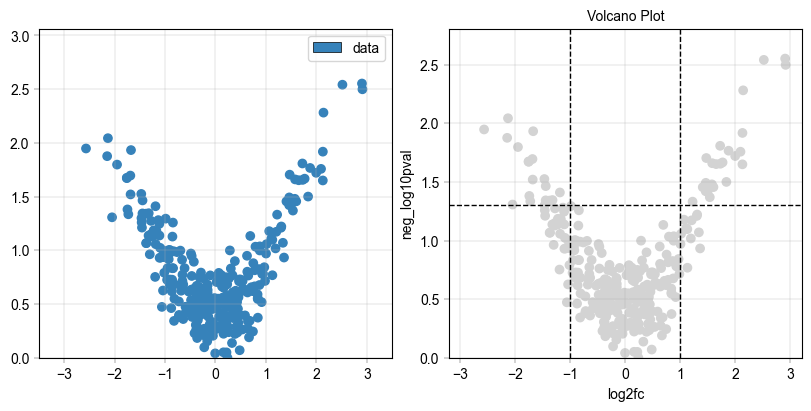

In [ ]:
from alphapepttools import pl

# As usual, we start with a figure and an axis manager that allows us to easily traverse subplots
fig, axm = pl.create_figure(1, 2, figsize=(8, 4))

# Scatterplot
Plots.scatter(
    ax=axm.next(),
    data=vp_data,
    x_column="log2fc",
    y_column="neg_log10pval",
    default_group="data",
    legend="auto",
)

# Volcanoplot, with some defaults for title, lines and labels
Plots.volcano(
    ax=axm.next(),
    data=vp_data,
    x_column="log2fc",
    y_column="neg_log10pval",
    default_group="data",
    legend="auto",
)

## Advanced layering in a volcanoplot

The volcanoplot makes use of `alphapepttools`' capability for layered visualizations and summarizes some convenient plot elements into a single wrapper function. 

For example, given this plot_layers definition, we specify that we want to plot proteins of interest with a specific hypothesis attached _above_ proteins belonging to the 'POI' category in general, below which up/down/and non-regulated points should be shown:

In [ ]:
pois = ["P10291", "P10292", "P10293", "P10294", "P10295"]
plot_layers = [
    # look for all points in the "id" column that are in the pois list and color them according to the "POI_hypothesis" color in the color_dict
    ("id", pois, "POI_hypothesis"),
    # look for all points that have "POI" in the "label" column and color them according to the "POI" color in the color_dict
    ("label", "POI", "POI"),  # in the second layer, plot all points where the label is "POI"
    # similar for regulation status
    ("diff_exp_status", "upregulated", "upregulated"),
    ("diff_exp_status", "downregulated", "downregulated"),
    ("diff_exp_status", "unchanged", "unchanged"),
]

We need a `color_dict` which specify how to color each layer:

In [ ]:
color_dict = {
    "upregulated": BaseColors.get("orange"),  # the specific point "P10001" should be colored orange
    "downregulated": BaseColors.get("blue"),  # the specific point "P10002" should be colored blue
    "unchanged": BaseColors.get("grey"),  # points from the list ["P10002", "P10003", "P10004"] should be colored grey
    "POI": "black",  # points where the label is "POI" should be colored black
    "POI_hypothesis": BaseColors.get("purple", lighten=0.7),  # points in the pois list should be colored purple
}

Additionally, we specify which points to add labels to by referencing their key in `color_dict`:

In [ ]:
label_layers = [
    "POI",  # label all points where the label is "POI"
    "POI_hypothesis",  # label all points in the pois list
]

### Essentially, 
we create a volcanoplot that's saying "put regulated points in the background, highlight POIs in black and special 
hypothesis POIs in purple on top. Additionally, add labels only to the first two layers."

### Generating the volcanoplot with labels

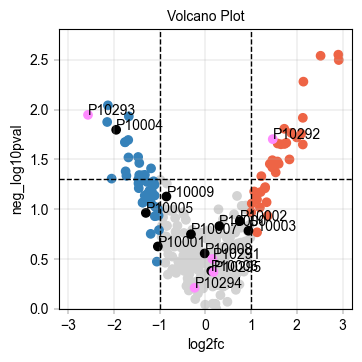

In [ ]:
Plots.volcano(
    data=vp_data,
    x_column="log2fc",
    y_column="neg_log10pval",
    color_dict=color_dict,
    layers=plot_layers,
    label_layers=label_layers,
)

### However, direct labelling is sub-optimal...

While this achieves the plotting per se, overlapping labels are illegible and dodge/jitter solutions often produce scattered-looking plots that don't scale down well. We address this by resorting to _anchored stacked labels_, where we specify a number of x-axis anchors above which labels should be stacked vertically. This makes the plot much tidier, allows for clean labelling of more points and makes it very easy to scale down a plot to adapt to limited publication figure real estate.

### Generate volcanoplot with anchored stacked labels

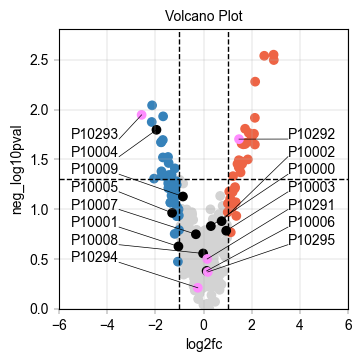

In [ ]:
Plots.volcano(
    data=vp_data,
    x_column="log2fc",
    y_column="neg_log10pval",
    color_dict=color_dict,
    layers=plot_layers,
    label_layers=label_layers,
    x_label_anchors=[-3.5, 3.5],  # Put label columns in these positions (nearest points are assigned to either one)
    y_padding_factor=1.7,  # How much vertical space to add between labels
    y_display_start=0.75,  # Where to start the top label display (0 = bottom, 1 = top)
    xlims=(-6, 6),
)

### Scaling down the volcanoplot to fit in a single paper figure tile

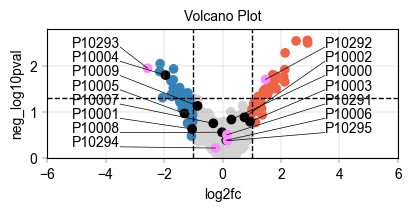

In [ ]:
fig, axm = pl.create_figure(1, 1, figsize=(4, 2))

Plots.volcano(
    ax=axm.next(),
    data=vp_data,
    x_column="log2fc",
    y_column="neg_log10pval",
    color_dict=color_dict,
    layers=plot_layers,
    label_layers=label_layers,
    x_label_anchors=[-3.5, 3.5],  # Put label columns in these positions (nearest points are assigned to either one)
    y_padding_factor=1.7,  # How much vertical space to add between labels
    y_display_start=1,  # Where to start the top label display (0 = bottom, 1 = top)
    xlims=(-6, 6),
)

### Summary:

- `alphapepttools` allows for generating volcanoplots with flexible coloring and labeling.

- anchored stacked labels allow for more organized, smaller scatterplots.

- The underlying function `pl.layered_plot` can be used to generate layered plots in a generalized way (described in the notebook `tutorials/tutorial_02_basic_plotting_workflow.iypnb`).